# Exercise: Viewing the world in new ways using remote sensing data

We discussed in our last section that natural color imagery is based on three color bands: red, green, and blue, which each correspond to the measurements of a sensor (i.e. a camera) collecting information on the wavelengths of light that correspond to the colors red (625-750 nm), green (500-565nm), and blue (450-485nm). These are the colors our built-in sensors (eyeballs) can detect. However, there are many other wavelengths to explore. Frequently, when we're working with remote sensing data from satellites, we do not solely care about RGB data, but also infrared data that measures light around 840nm in wavelength. Near-infrared (NIR) data can be exceptionally informative for learning about the presence and health of vegetation which can be useful for agriculture as well as understanding the degree of urban development in a region.

In this exercise, you'll explore how we can work with matrices to gain more information about vegetation in a region using a collection of satellite imagery from Kansas, USA from the Sentinel-2 instrument of the European Space Administration (ESA). You can explore publicly available ESA data at https://scihub.copernicus.eu/dhus/.

Let's take a look at each band individually, then the RGB bands together for a standard natural color image. From there we'll take a look at a false color infrared image which will provide information on the relative health of the vegetation. Lastly, we'll explore the normalized difference vegetation index (NDVI) which is used to quantify the amount of vegetation present in a region.

We'll get started by loading are data as a set of three separate matrices representing the red, blue, green, and NIR bands of our data. Here's the code to get you started. Running this code loads four numpy arrays, one for red, green, blue, and NIR: `band2_blue`, `band3_green`, `band4_red`, and `band8_nir`.

In [8]:
from matplotlib import image
import matplotlib.pyplot as plt
import numpy as np

# Load the data from each of the four bands
band2_blue = image.imread(f"B02.png")
band3_green = image.imread(f"B03.png")
band4_red = image.imread(f"B04.png")
band8_nir = image.imread(f"B08.png")

In [16]:
band2_blue.shape

(1000, 1000)

In [9]:

def plot_image(im, colormap='Greys_r'):
    '''Plots either a single band or a 3-band image, depending on whether `im` is 2-D or 3-D 
    For single band images, you can specify the colormap or the default of 'Greys_r' is chosen.
    '''
    fig, ax = plt.subplots(figsize=(8,8))
    perc = 5
    percentiles = np.percentile(im,[perc,100-perc])
    if im.ndim == 3:
        ax.imshow(im*3) # The mutiplication increases the image brightness for easier viewing
    elif im.ndim == 2:
        ax.imshow(im,cmap=colormap,vmin=percentiles[0], vmax=percentiles[1])
    plt.show()

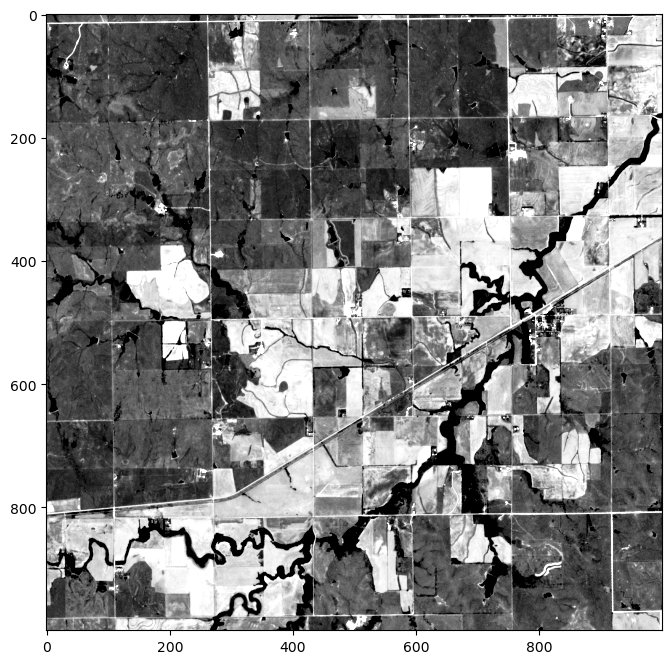

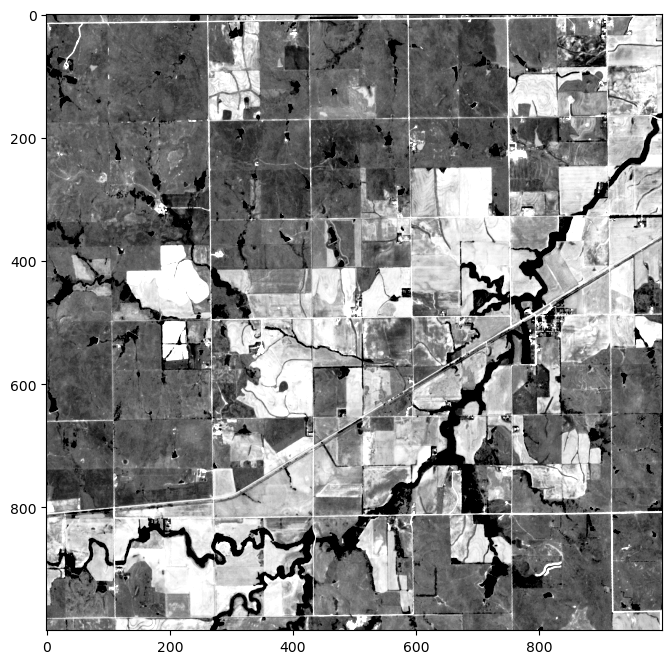

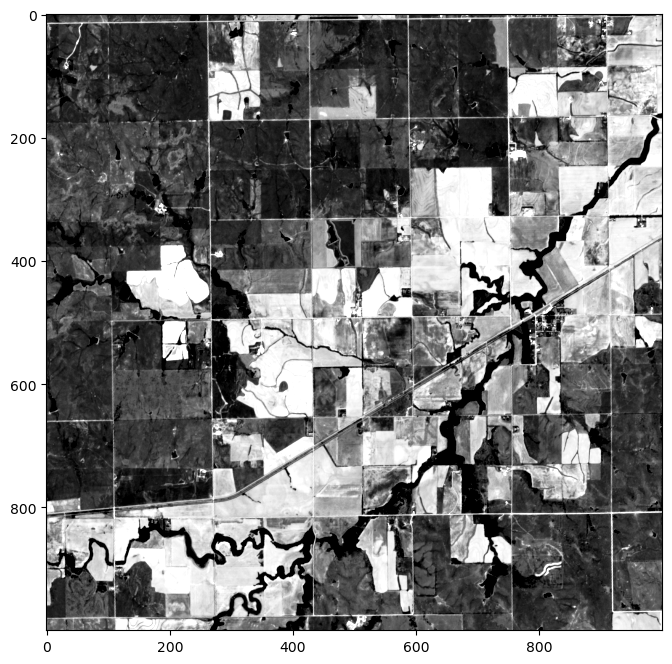

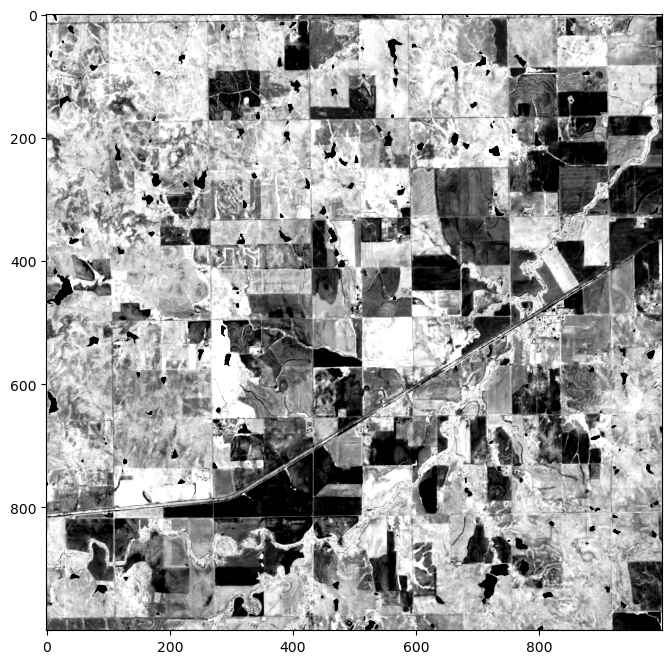

In [11]:
#use this code cell to write some code that will individually plot each of the four arrays in grayscale 
bands=[band2_blue,band3_green,band4_red,band8_nir]
for im in bands:
    plot_image(im)

In [27]:
#use this code cell to use the numpy stack method, and combine your red, green, and blue arrays into a 3-D array and plot it
bands=[band2_blue,band3_green,band4_red,band8_nir]
im_natural_colour=np.stack((band4_red,band3_green,band2_blue),axis=-1)
im_natural_colour.shape

(1000, 1000, 3)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.0].


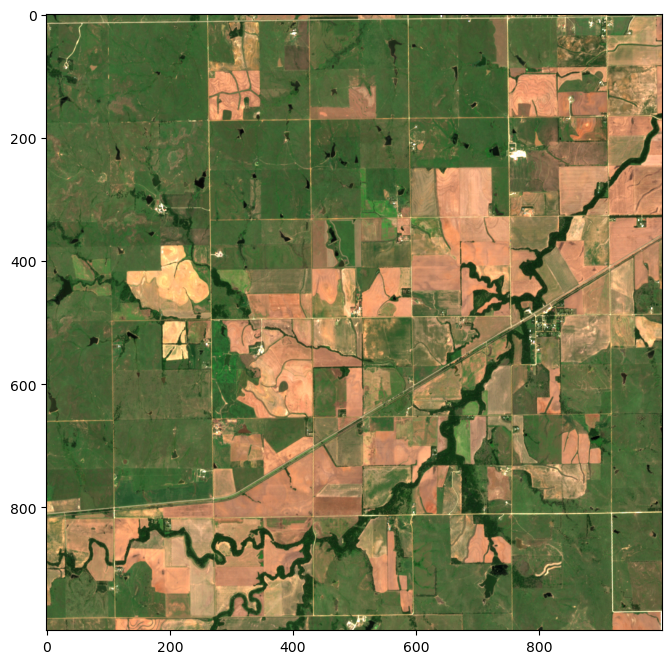

In [28]:
plot_image(im_natural_colour)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.0].


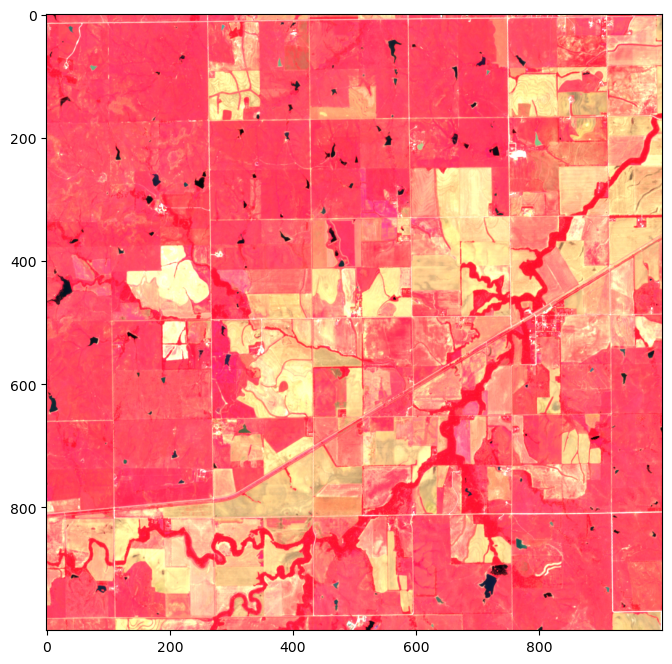

In [30]:
#use this code cell to plot a 3-D array, with (NIR, Red, Green) as your colors instead of (Red, Green, Blue)
#bands=[band2_blue,band3_green,band4_red,band8_nir]
im_false_colour=np.stack((band8_nir,band4_red,band3_green),axis=-1)
plot_image(im_false_colour)

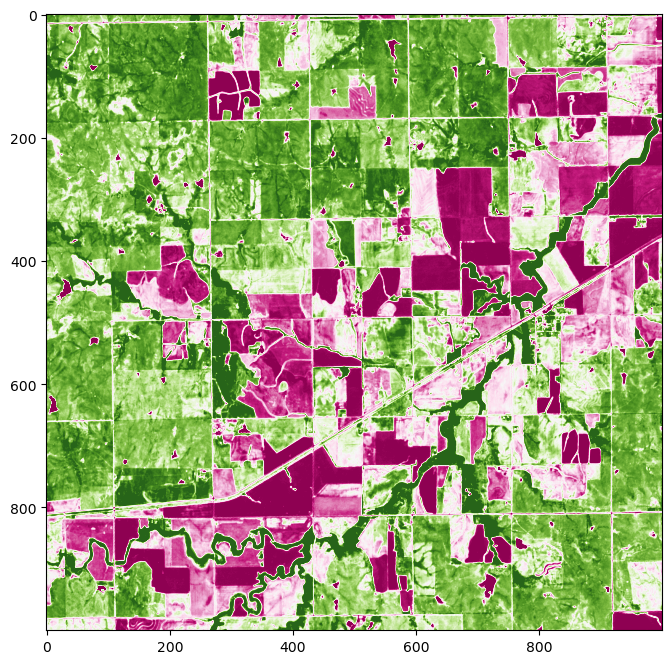

In [32]:
#use this code cell to calculate the NDVI, and then plot it using the PiYG colormap
#refer to earlier in this exercise when we defined the plot_image function to see how to specify colormaps

in_ndvi=((band8_nir-band4_red)/(band8_nir+band4_red))
plot_image(in_ndvi,colormap='PiYG')